# IA: Exercícios no Colab (pré-processamento)
**Author**: Rodrigo Andrade

**GitHub**: https://github.com/Rorchive/PFT-xGMobile

**Language**: Python

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# ==========================================
# STEP 1: DATAFRAME
# ==========================================
data = {
    'id_sensor': [101, 102, 103, 104, 101, 105, 106, 107, 108, 109],
    'localizacao': ['Setor A', 'Setor B', 'Setor A', 'Setor C', 'Setor A', 'Setor B', 'Setor C', 'Setor A', np.nan, 'Setor B'],
    'consumo_kwh': [150.5, 3200.0, 150.5, 2100.0, 150.5, np.nan, 4500.0, 120.0, 5000.0, 250.0],
    'temperatura_operacao': [25.4, 65.2, 25.4, np.nan, 25.4, 40.0, 85.0, 22.0, 90.0, 30.5],
    'status': ['Ativo', 'Alerta', 'Ativo', 'Inativo', 'Ativo', 'Ativo', 'Alerta', 'Ativo', 'Critico', 'Inativo']
}

df = pd.DataFrame(data)
df

,id_sensor,localizacao,consumo_kwh,temperatura_operacao,status
0,101,Setor A,150.5,25.4,Ativo
1,102,Setor B,3200.0,65.2,Alerta
2,103,Setor A,150.5,25.4,Ativo
3,104,Setor C,2100.0,NaN,Inativo
4,101,Setor A,150.5,25.4,Ativo
5,105,Setor B,NaN,40.0,Ativo
6,106,Setor C,4500.0,85.0,Alerta
7,107,Setor A,120.0,22.0,Ativo
8,108,NaN,5000.0,90.0,Critico
9,109,Setor B,250.0,30.5,Inativo


In [47]:
# ==========================================
# STEP 2: CLEANING
# ==========================================

df = df.drop_duplicates(ignore_index=True).copy() # Remove duplicates
df['id_sensor'] = df['id_sensor'].fillna(df['id_sensor'].mean()) # Replace null values by mean values
df['consumo_kwh'] = df['consumo_kwh'].fillna(df['consumo_kwh'].mean())
df['temperatura_operacao'] = df['temperatura_operacao'].fillna(df['temperatura_operacao'].mean())

df.dropna(subset=['localizacao', 'status'], inplace=True, ignore_index=True) # Remove NaN values from 'localizacao' and 'status'

df

,id_sensor,localizacao,consumo_kwh,temperatura_operacao,status
0,101,Setor A,150.500,25.4000,Ativo
1,102,Setor B,3200.000,65.2000,Alerta
2,103,Setor A,150.500,25.4000,Ativo
3,104,Setor C,2100.000,47.9375,Inativo
4,105,Setor B,1933.875,40.0000,Ativo
5,106,Setor C,4500.000,85.0000,Alerta
6,107,Setor A,120.000,22.0000,Ativo
7,109,Setor B,250.000,30.5000,Inativo


In [48]:
# ==========================================
# STEP 3: CODIFICATION
# ==========================================

df_codified = pd.get_dummies(df, columns=['status', 'localizacao'])

df_codified

,id_sensor,consumo_kwh,temperatura_operacao,status_Alerta,status_Ativo,status_Inativo,localizacao_Setor A,localizacao_Setor B,localizacao_Setor C
0,101,150.500,25.4000,False,True,False,True,False,False
1,102,3200.000,65.2000,True,False,False,False,True,False
2,103,150.500,25.4000,False,True,False,True,False,False
3,104,2100.000,47.9375,False,False,True,False,False,True
4,105,1933.875,40.0000,False,True,False,False,True,False
5,106,4500.000,85.0000,True,False,False,False,False,True
6,107,120.000,22.0000,False,True,False,True,False,False
7,109,250.000,30.5000,False,False,True,False,True,False


In [49]:
# ==========================================
# STEP 4: NORMALIZATION
# ==========================================

scaler = MinMaxScaler()

# Apply scaler to all numerical columns in df_codified
df_normalized = pd.DataFrame(scaler.fit_transform(df_codified), columns=df_codified.columns)

df_normalized

,id_sensor,consumo_kwh,temperatura_operacao,status_Alerta,status_Ativo,status_Inativo,localizacao_Setor A,localizacao_Setor B,localizacao_Setor C
0,0.000,0.006963,0.053968,0.0,1.0,0.0,1.0,0.0,0.0
1,0.125,0.703196,0.685714,1.0,0.0,0.0,0.0,1.0,0.0
2,0.250,0.006963,0.053968,0.0,1.0,0.0,1.0,0.0,0.0
3,0.375,0.452055,0.411706,0.0,0.0,1.0,0.0,0.0,1.0
4,0.500,0.414127,0.285714,0.0,1.0,0.0,0.0,1.0,0.0
5,0.625,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,1.0
6,0.750,0.000000,0.000000,0.0,1.0,0.0,1.0,0.0,0.0
7,1.000,0.029680,0.134921,0.0,0.0,1.0,0.0,1.0,0.0


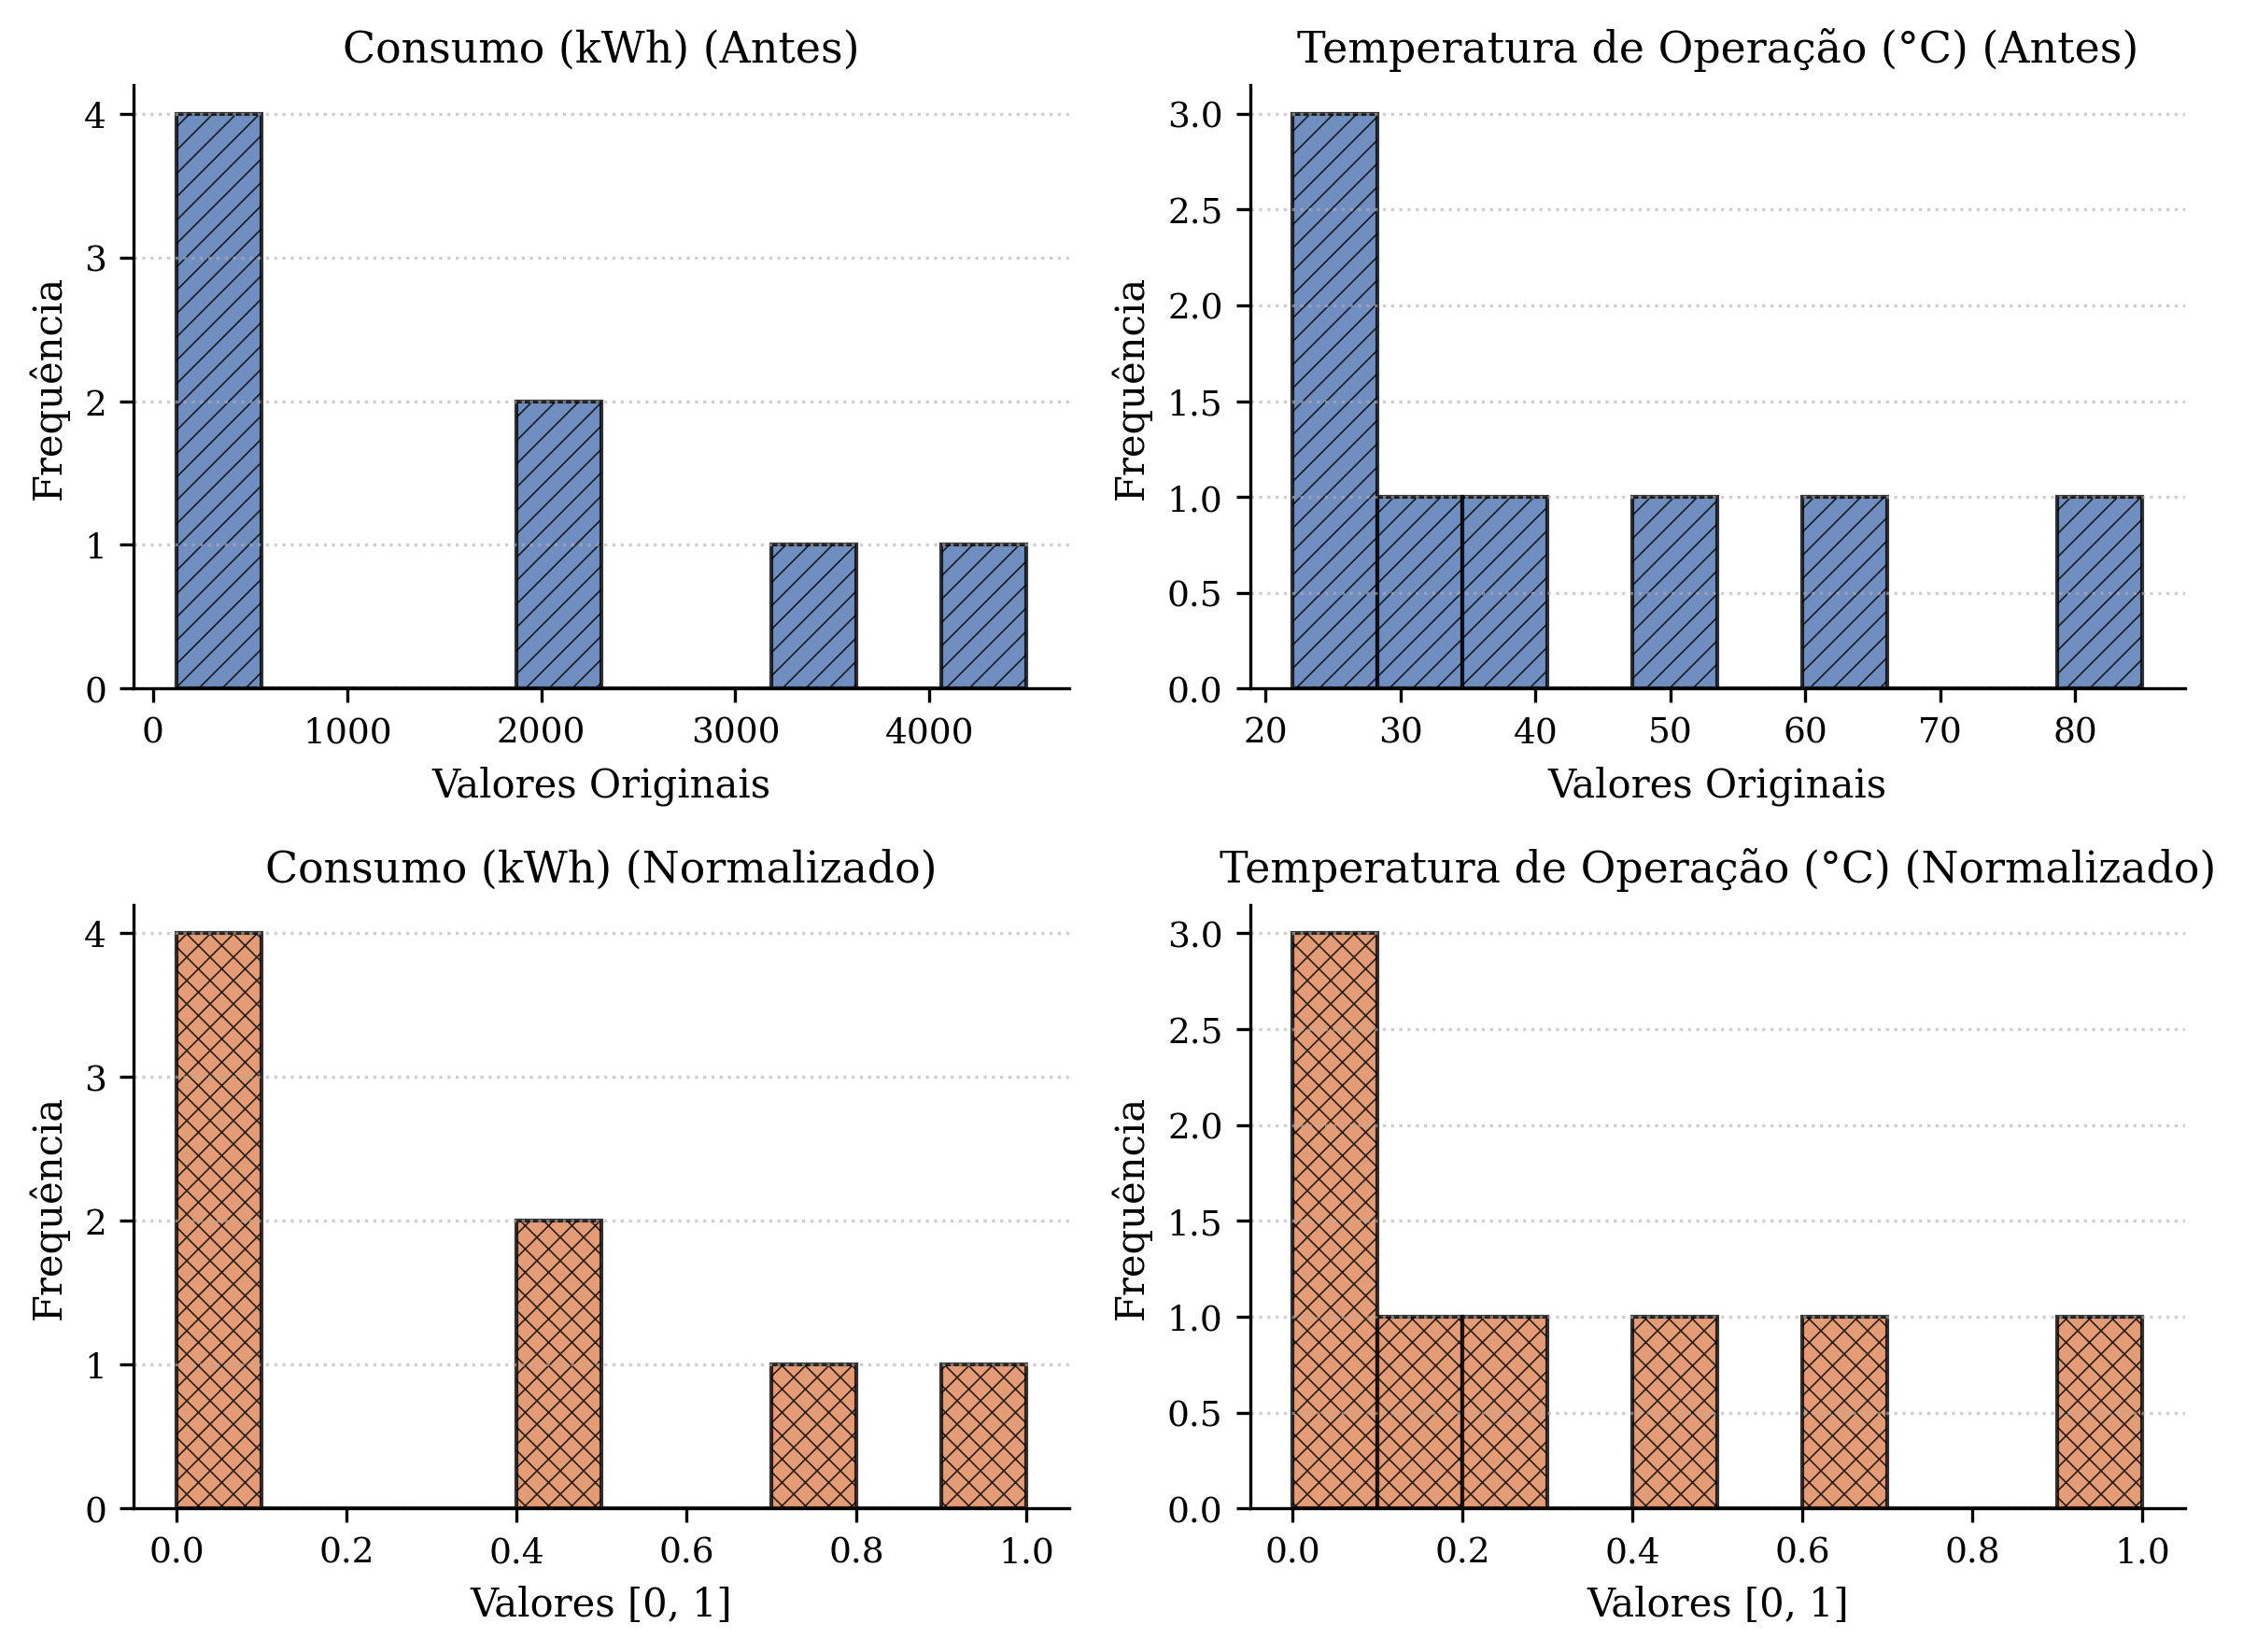

In [50]:
# ==========================================
# STEP 5: PLOTING (Paper/IEEE Format)
# ==========================================

# 1. Global Matplotlib IEEE Configuration
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'], # Font
    'font.size': 10,           # Font Size
    'axes.labelsize': 10,      # Labels (X e Y)
    'axes.titlesize': 11,      # Graphic Titles
    'xtick.labelsize': 9,      # Values X
    'ytick.labelsize': 9,      # Values Y
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'hatch.linewidth': 0.4,
})

# Contionous variables
num_cols = ['consumo_kwh', 'temperatura_operacao']
col_names = ['Consumo (kWh)', 'Temperatura de Operação (°C)']

# Creating figure
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))

# Colors
color_before = '#4C72B0'   # Blue
color_after = '#DD8452'  # Orange

for i, col in enumerate(num_cols):

    # --- BEFORE NORMALIZATION (ROW 0) ---
    ax_before = axes[0, i]
    ax_before.hist(df_codified[col], bins=10, color=color_before, edgecolor='black', alpha=0.8, hatch='////')
    ax_before.set_xlabel("Valores Originais")
    ax_before.set_title(f"{col_names[i]} (Antes)")
    ax_before.set_ylabel("Frequência")

    ax_before.grid(axis='y', linestyle=':', alpha=0.6)
    ax_before.spines['top'].set_visible(False)
    ax_before.spines['right'].set_visible(False)

    # --- AFTER NORMALIZATION (ROW 1) ---
    ax_after = axes[1, i]
    ax_after.hist(df_normalized[col], bins=10, color=color_after, edgecolor='black', alpha=0.8, hatch='xxxx')
    ax_after.set_title(f"{col_names[i]} (Normalizado)")
    ax_after.set_xlabel("Valores [0, 1]")
    ax_after.set_ylabel("Frequência")

    ax_after.grid(axis='y', linestyle=':', alpha=0.6)
    ax_after.spines['top'].set_visible(False)
    ax_after.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()